In [1]:
import os
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn import metrics

2026-02-21 19:49:21.742828: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
def ela(image_path, scale=(224, 224), quality=90):
    image = Image.open(image_path).convert('RGB')
    image = image.resize(scale)

    buffer = BytesIO()
    image.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)

    compressed = Image.open(buffer)

    diff = np.abs(
        np.array(image, dtype=np.int16) - np.array(compressed, dtype=np.int16)
    )
    diff = np.clip(diff * 10, 0, 255).astype(np.uint8)

    return diff

In [ ]:
model_path = os.path.join('models', 'deforge-ela.keras')
model = tf.keras.models.load_model(model_path)

print('Model loaded successfully.')

I0000 00:00:1771696168.736307   66278 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2549 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model loaded successfully.


2026-02-21 19:49:29.758932: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 44302336 exceeds 10% of free system memory.
2026-02-21 19:49:29.847428: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 44302336 exceeds 10% of free system memory.
2026-02-21 19:49:29.904426: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 44302336 exceeds 10% of free system memory.


In [ ]:
IMAGE_SIZE = (224, 224)
BASE_DIR = 'data'
CLASSES = ['fake', 'real']

X = []
y_true = []
paths = []

for label, cls in enumerate(CLASSES):
    folder = os.path.join(BASE_DIR, cls)

    for file in os.listdir(folder):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(folder, file)

            ela_img = ela(img_path, IMAGE_SIZE)
            ela_img = ela_img.astype(np.float32) / 255.0

            X.append(ela_img)
            y_true.append(label)
            paths.append(img_path)

X = np.array(X)
y_true = np.array(y_true)

print(f'Loaded {len(X)} images')

Loaded 40 images


In [5]:
y_pred_probs = model.predict(X, batch_size=32)
y_pred = np.argmax(y_pred_probs, axis=1)

2026-02-21 19:49:30.783416: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 24084480 exceeds 10% of free system memory.
2026-02-21 19:49:30.818246: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19267584 exceeds 10% of free system memory.
2026-02-21 19:49:30.895307: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f5c84005b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-21 19:49:30.895330: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti, Compute Capability 7.5
2026-02-21 19:49:30.908265: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-21 19:49:30.977035: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-21 19:49:31.521926: I external/local_x

1/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

I0000 00:00:1771696172.960555   66413 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-02-21 19:49:33.177729: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,32,222,222]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3,224,224]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-21 19:49:33.229084: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,109,109]{3,2,1,0}, u8[0]{0}) custom-call(f3

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 936ms/step


In [ ]:
print(metrics.classification_report(y_true, y_pred, target_names=CLASSES))

print('ROC AUC:', metrics.roc_auc_score(y_true, y_pred))
print('Average Precision:', metrics.average_precision_score(y_true, y_pred))

              precision    recall  f1-score   support

        fake       1.00      0.45      0.62        20
        real       0.65      1.00      0.78        20

    accuracy                           0.72        40
   macro avg       0.82      0.72      0.70        40
weighted avg       0.82      0.72      0.70        40

ROC AUC: 0.725
Average Precision: 0.6451612903225806


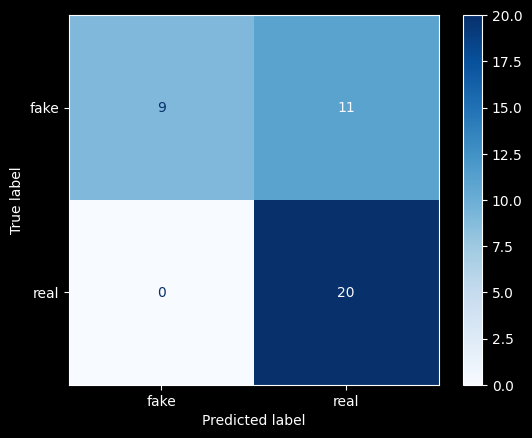

In [ ]:
cm = metrics.confusion_matrix(y_true, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap='Blues')
plt.show()

In [ ]:
for i in range(len(paths)):
    if y_true[i] != y_pred[i]:
        print(
            f'WRONG | {paths[i]} | '
            f'GT: {CLASSES[y_true[i]]} | '
            f'PRED: {CLASSES[y_pred[i]]}'
        )

WRONG | data/fake/11.jpeg | GT: fake | PRED: real
WRONG | data/fake/12.jpeg | GT: fake | PRED: real
WRONG | data/fake/13.jpeg | GT: fake | PRED: real
WRONG | data/fake/14.jpeg | GT: fake | PRED: real
WRONG | data/fake/15.jpeg | GT: fake | PRED: real
WRONG | data/fake/17.jpeg | GT: fake | PRED: real
WRONG | data/fake/19.jpeg | GT: fake | PRED: real
WRONG | data/fake/20.jpeg | GT: fake | PRED: real
WRONG | data/fake/3.jpg | GT: fake | PRED: real
WRONG | data/fake/5.jpg | GT: fake | PRED: real
WRONG | data/fake/6.jpg | GT: fake | PRED: real


In [ ]:
def show_prediction_grid(
    paths,
    y_true,
    y_pred,
    class_names,
    grid_size=(4, 5),
    max_images=20,
):
    idxs = np.random.choice(len(paths), min(max_images, len(paths)), replace=False)

    rows, cols = grid_size
    plt.figure(figsize=(cols * 3, rows * 3))

    for i, idx in enumerate(idxs):
        if i >= rows * cols:
            break

        img = Image.open(paths[idx]).convert('RGB')

        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        color = 'green' if true_label == pred_label else 'red'

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f'P: {pred_label}\nGT: {true_label}', color=color, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


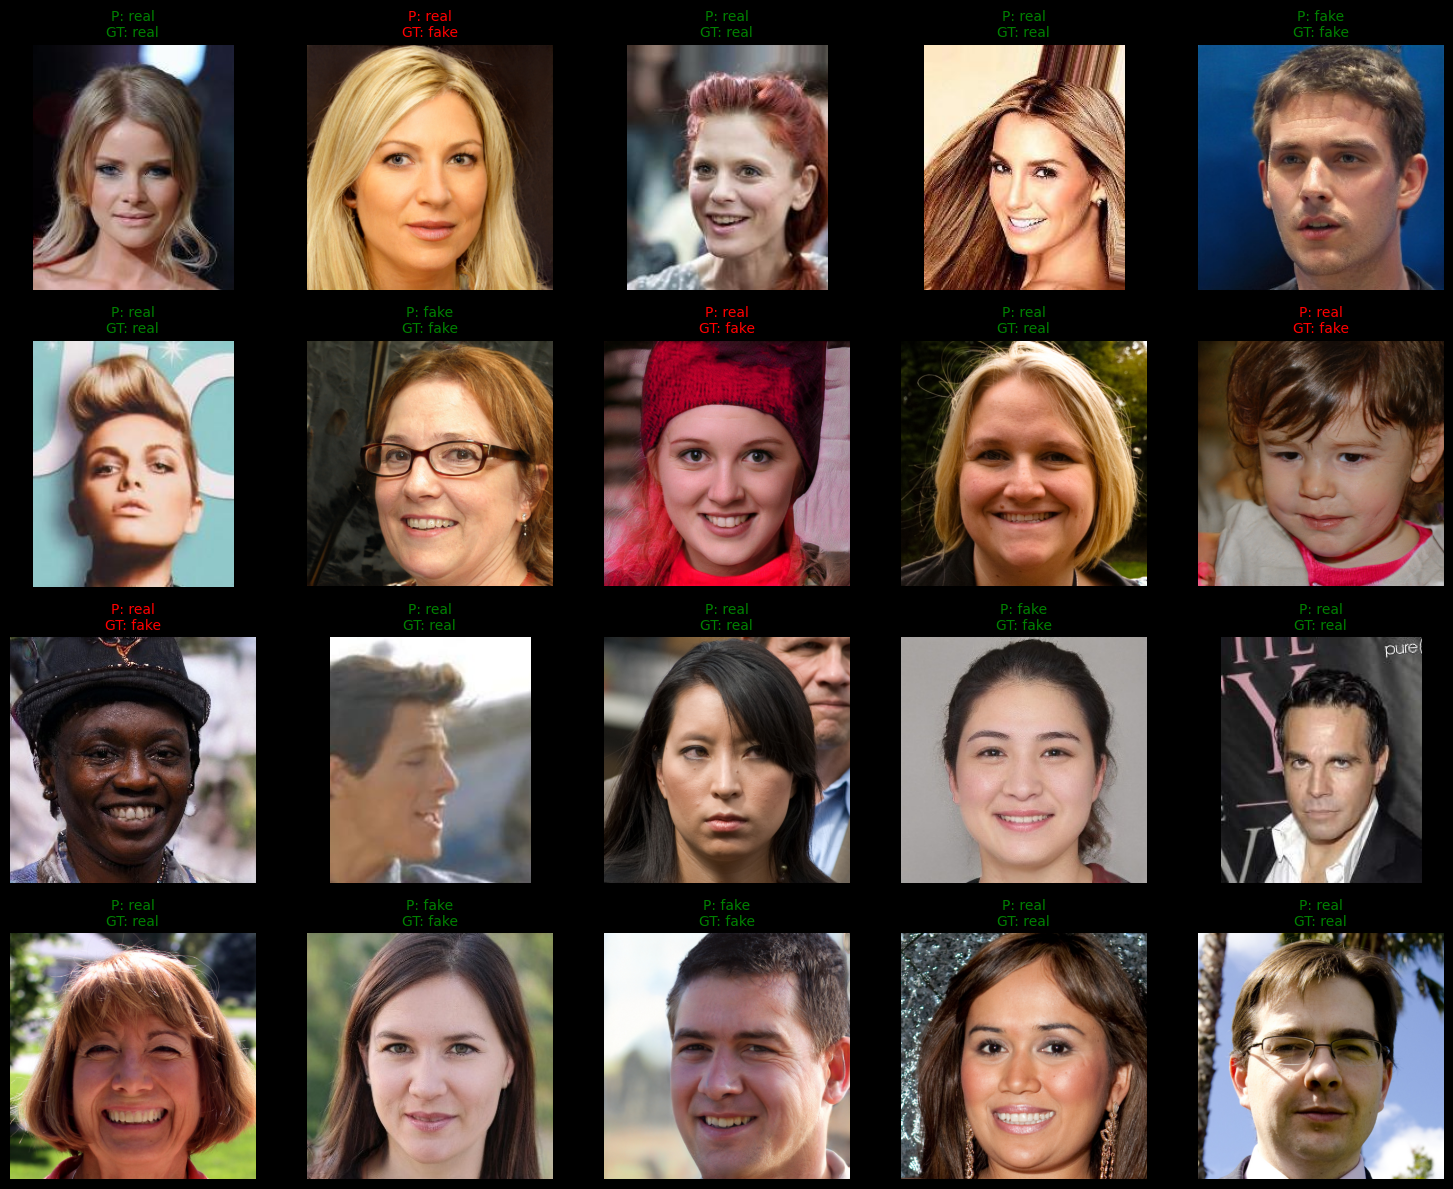

In [10]:
show_prediction_grid(paths=paths, y_true=y_true, y_pred=y_pred, class_names=CLASSES)